In [7]:
import pygeohydro as gh
import geopandas as gpd
import matplotlib.pyplot as plt
import pyogrio
import numpy as np
import datashader as ds
import datashader.transfer_functions as tf
import colorcet as cc
from datashader.utils import export_image


#jurisdiction layer has our area of interest (aoi) boundary. here we load it.
aoi = gpd.read_file("../aoi_layer/NoVA_Boundaries.geojson")

#file's coordinate reference system EPSG:4326
aoi.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [9]:
#now reading building data and cropping to aoi boundary
building_cropped = gpd.read_file("./Deliverable20250606VA/VA_Structures.gdb", layer=0, engine='pyogrio', mask=aoi)
building_cropped.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

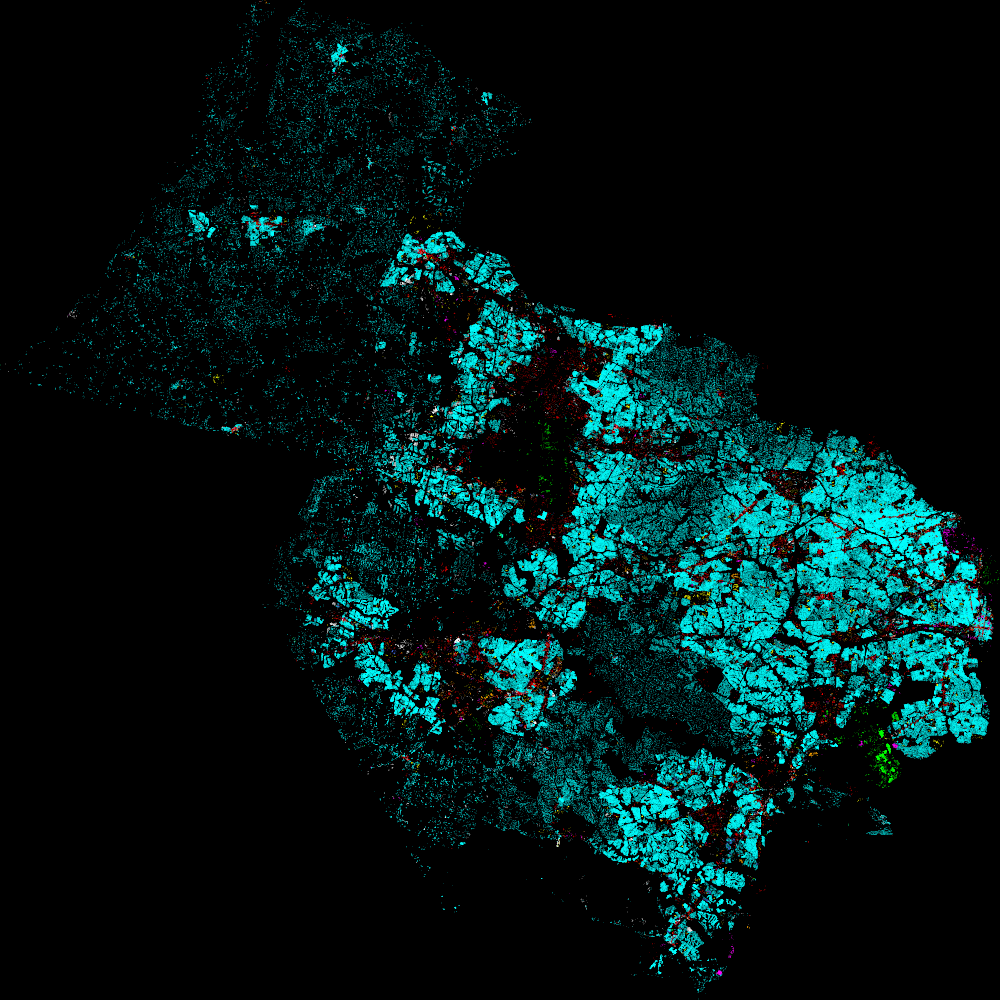

In [10]:
#needed to convert file to parquet because it was too large and inefficent as a gpd file
building_cropped.to_parquet("buildings_fitted.parquet")
buildings_fitted = gpd.read_parquet("buildings_fitted.parquet")

cvs = ds.Canvas(plot_width=1000, plot_height=1000)

#aggregate by the 'OCC_CLS' column 
buildings_fitted['OCC_CLS'] = buildings_fitted['OCC_CLS'].astype('category')

# ds.count_cat colors pixels based on building category OCC_CLS
agg = cvs.polygons(buildings_fitted, geometry='geometry', agg=ds.count_cat('OCC_CLS'))

img = tf.shade(agg, color_key={'Residential': 'cyan',
    'Assembly': 'royalblue',
    'Commercial': 'red',
    'Government': 'magenta',
    'Education': 'yellow',
    'Industrial': 'orange',
    'Agriculture': 'springgreen',
    'Utility and Misc': 'lime',
    'Unclassified': 'white'}) 

buildings_img = tf.set_background(img, "black")
buildings_img

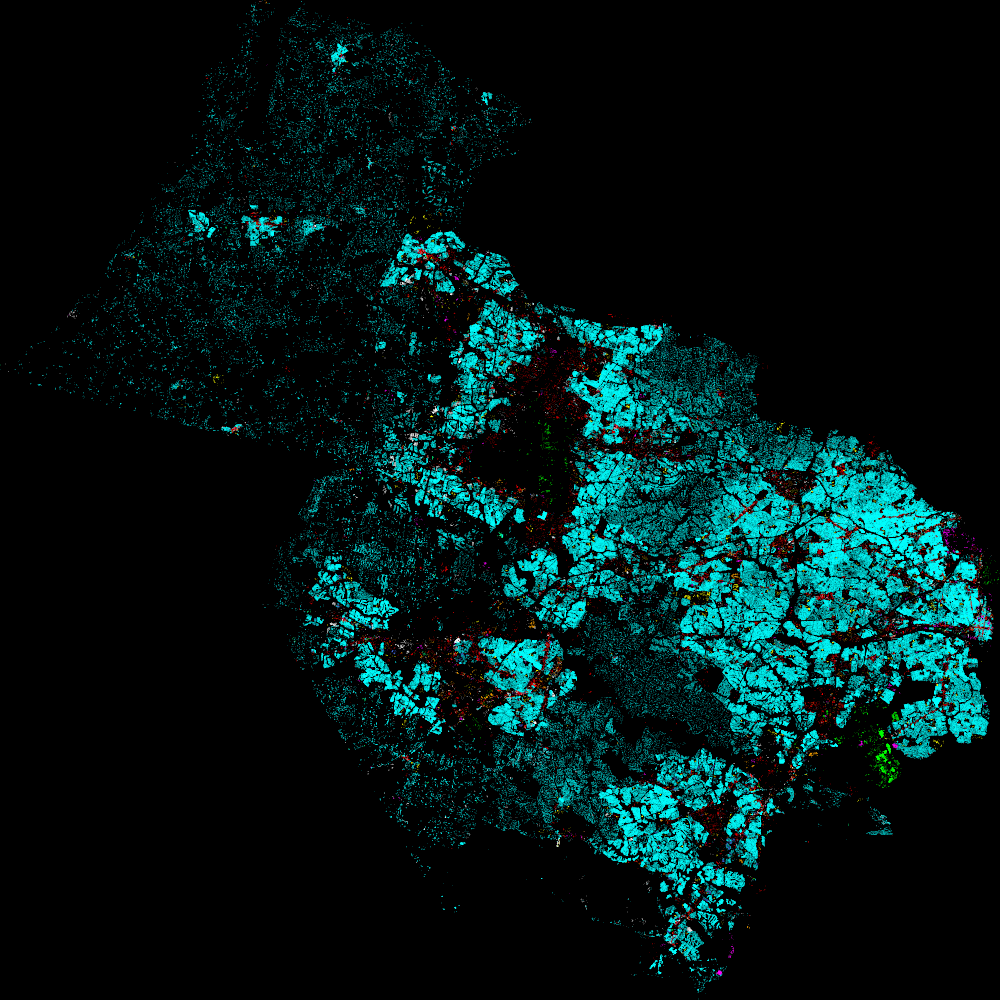

: 

In [ ]:

export_image(buildings_img, "buildings_map", export_path=".", fmt=".png")